# Custom Dataset Example: AI4PT Video Tracks

MobiML ships with a handful of built-in `Dataset` subclasses (see `mobiml-datasets.ipynb`), but real projects usually have their own data formats. This notebook shows how little code is needed to plug a new source into MobiML by subclassing `Dataset` **in your own code** -- no changes to the mobiml library are required.

As an example, we use tracking data exported from the AI4PT project's multi-camera video pipeline (see the [AI4PT project page](https://projekte.ffg.at/projekt/5121351)).

## The data format

`ai4pt_block_214.ntxy` contains one row per detected object per video frame:

| column | meaning |
| --- | --- |
| `timestamp` | Unix time in milliseconds |
| `tracking_id` | id of the tracked object; when two tracks are re-identified as the same object, their ids are joined with `_`, e.g. `2_-4_0_3_-7_0` |
| `pos_x`, `pos_y` | pixel position in the (stitched, multi-camera) video frame |

This is not one of MobiML's built-in formats, and the `.ntxy` file extension isn't recognized by the base `Dataset` loader (it only knows `.csv`, `.pickle`, `.feather`, `.zip`, or files loadable via `geopandas.read_file`). The file itself is just comma-separated text though, so we only need to override `load_from_path` to read it, and normalize a couple of columns.

In [1]:
import sys
sys.path.append("../src")

import warnings
from os.path import exists

import pandas as pd
from mobiml.datasets import Dataset, TIMESTAMP
from movingpandas.unit_utils import MissingCRSWarning

# our pixel coordinates have no CRS by design (crs = None below), so silence
# movingpandas' warning about it
warnings.filterwarnings("ignore", category=MissingCRSWarning)

## Define the dataset class

In [2]:
class VideoTracks(Dataset):
    name = "AI4PT Video Tracks"
    file_name = "ai4pt_block_<block_id>.ntxy"
    source_url = "https://projekte.ffg.at/projekt/5121351"  # replace with Zenodo dataset url
    traj_id = "tracking_id"
    mover_id = "tracking_id"
    timestamp = "timestamp"
    crs = None

    def __init__(self, path, *args, **kwargs) -> None:
        super().__init__(path, *args, **kwargs)

        self.df[TIMESTAMP] = pd.to_datetime(self.df[TIMESTAMP], unit="ms")
        self.df.rename(columns={"pos_x": "x", "pos_y": "y"}, inplace=True)

        print(f"Loaded Dataframe with {len(self.df)} rows.")

    def load_from_path(self, path, *args, **kwargs) -> pd.DataFrame:
        if not exists(path):
            msg = (
                f"Error reading from {path}: \r\n"
                + f"Please specify the path to the '{self.name}' "
                + f"file {self.file_name}"
            )
            if self.source_url:
                msg = f"{msg}\r\nYou may download this dataset from: {self.source_url}"
            raise ValueError(msg)
        return pd.read_csv(path, *args, **kwargs)

A few things worth noting:

- `Dataset.__init__` already takes care of the generic bookkeeping: it renames the columns to MobiML's standard `timestamp`/`traj_id`/`mover_id`.
- Since `tracking_id` already uniquely identifies a track (including merged ones), we set both `traj_id` and `mover_id` to it.
- `load_from_path` only needs to be overridden because `.ntxy` isn't a recognized extension -- the rest of the class (`to_df`, `to_gdf`, `to_trajs`, `plot`, ...) is inherited for free.
- The coordinates are video pixel positions rather than geographic coordinates, so `crs = None`.

## Load the example block

In [3]:
tracks = VideoTracks(r"../examples/data/ai4pt_block_214.ntxy")
tracks.df.head()

Loaded Dataframe with 15121 rows.


,timestamp,traj_id,x,y,mover_id
0,2024-10-03 17:54:25.480,0_1613_0,4069,686,0_1613_0
1,2024-10-03 17:54:25.480,0_1325_0,3633,270,0_1325_0
2,2024-10-03 17:54:25.480,0_1556_0,4330,671,0_1556_0
3,2024-10-03 17:54:25.480,0_1504_0,4144,139,0_1504_0
4,2024-10-03 17:54:25.480,0_1617_0,3648,224,0_1617_0


## Merged tracking ids

Re-identification events show up as tracking ids that join two previous ids, e.g. `2_-4_0_3_-7_0`. Because we treat `tracking_id` as an opaque string, these are preserved as-is and simply become their own trajectory.

In [4]:
tracks.df[tracks.df["traj_id"].str.count("_") > 2].head()

,timestamp,traj_id,x,y,mover_id
46,2024-10-03 17:54:25.679,0_1608_0_1_816_0,3416,177,0_1608_0_1_816_0
88,2024-10-03 17:54:25.881,2_1238_0_3_2123_0,1172,426,2_1238_0_3_2123_0
120,2024-10-03 17:54:26.077,2_1238_0_3_2123_0,1170,422,2_1238_0_3_2123_0
157,2024-10-03 17:54:26.257,2_1238_0_3_2123_0,1168,422,2_1238_0_3_2123_0
193,2024-10-03 17:54:26.435,2_1238_0_3_2123_0,1168,419,2_1238_0_3_2123_0


## Convert to trajectories

Because we mapped the data onto MobiML's standard columns, all of the usual `Dataset` conveniences work out of the box, e.g. `to_trajs()` to get a movingpandas `TrajectoryCollection`. Note that tracks with fewer than two positions are dropped, so this will be fewer than the number of unique tracking ids.

In [5]:
trajs = tracks.to_trajs()
len(trajs), tracks.df["traj_id"].nunique()

(252, 1398)

## Plot

<Axes: >

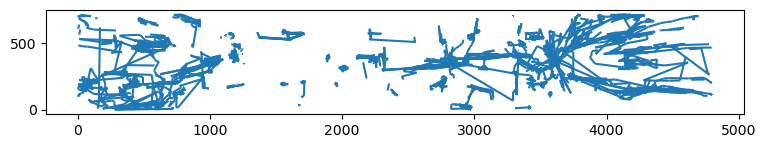

In [6]:
trajs.plot(figsize=(9, 3))

<Axes: >

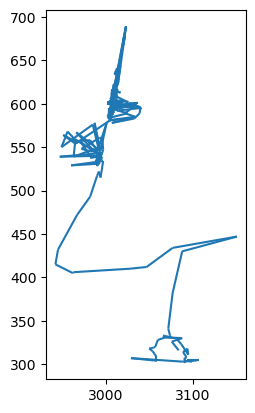

In [7]:
traj = trajs.get_trajectory("1_1074_0")
traj.plot()

## Smoothing a trajectory with a Kalman filter

Video-based tracking positions are noisy: detector jitter and brief mix-ups between nearby objects show up as zig-zags in the raw trajectory. MobiML's `TrajectoryFilter` (in `mobiml.preprocessing`) has a `filter_kalman()` method that wraps movingpandas' `KalmanSmootherCV` -- it takes a `Dataset` in and returns a `Dataset` with smoothed positions, same as `filter_min_pts()` or `filter_speed()`.

This requires the optional [Stone Soup](https://stonesoup.readthedocs.io/en/latest/#installation) dependency (`stonesoup`, available on conda-forge).


In [8]:
from mobiml.preprocessing import TrajectoryFilter

smoothed_tracks = TrajectoryFilter(tracks.copy()).filter_kalman(
    process_noise_std=0.5, measurement_noise_std=1
)
len(tracks.df), len(smoothed_tracks.df)

(15121, 13975)

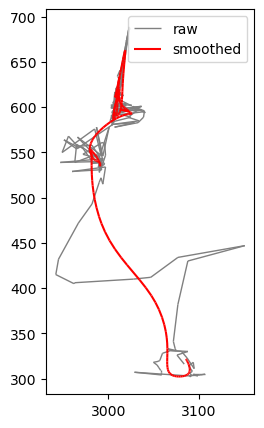

In [13]:
original_traj = tracks.to_trajs().get_trajectory("1_1074_0")
smoothed_traj = smoothed_tracks.to_trajs().get_trajectory("1_1074_0")

ax = original_traj.plot(color="gray", linewidth=1, label="raw", figsize=(5, 5))
smoothed_traj.plot(ax=ax, color="red", linewidth=1.5, label="smoothed")
ax.legend()